In [1]:
import pandas as pd
import numpy as np
import plotly.express as px


In [2]:
import os

os.getcwd()

'/Users/prudhvi/dataviz-exercises-prudhvisai/Final_Project/notebook/Netflix_Project.ipynb'

In [8]:
import os

print(os.getcwd())

print(os.listdir("."))

/Users/prudhvi/dataviz-exercises-prudhvisai/Final_Project/notebook/Netflix_Project.ipynb
['Untitled.ipynb', '.ipynb_checkpoints']


In [9]:
import os

os.chdir("/Users/prudhvi/dataviz-exercises-prudhvisai/Final_Project/notebook")

print(os.getcwd())
print(os.listdir("../data"))

/Users/prudhvi/dataviz-exercises-prudhvisai/Final_Project/notebook
['netflix_titles.csv']


In [10]:
import pandas as pd

df = pd.read_csv("../data/netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [11]:
print("Rows, Columns:", df.shape)

df.info()

Rows, Columns: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [12]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [13]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


# Netflix Movies and TV Shows Analysis

## Final Project

### Student: Prudhvi Sai

This project explores the Netflix Movies and TV Shows dataset using Python, Pandas and Plotly Express.

The goal is to understand the content available on Netflix through exploratory data analysis and visualisations.

In [16]:
# -----------------------------
# Data Cleaning
# -----------------------------

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')
# Fill missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


In [17]:
# -----------------------------
# Feature Engineering
# -----------------------------

# Extract the year and month a title was added to Netflix
df['added_year'] = df['date_added'].dt.year
df['added_month'] = df['date_added'].dt.month_name()

# Separate duration into numbers
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

# Create separate columns for Movies and TV Shows
df['duration_unit'] = df['duration'].str.extract('([A-Za-z ]+)')

print(df[['date_added',
          'added_year',
          'added_month',
          'duration',
          'duration_num',
          'duration_unit']].head())

  date_added  added_year added_month   duration  duration_num duration_unit
0 2021-09-25      2021.0   September     90 min          90.0           min
1 2021-09-24      2021.0   September  2 Seasons           2.0       Seasons
2 2021-09-24      2021.0   September   1 Season           1.0        Season
3 2021-09-24      2021.0   September   1 Season           1.0        Season
4 2021-09-24      2021.0   September  2 Seasons           2.0       Seasons


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8807 non-null   object        
 1   type           8807 non-null   object        
 2   title          8807 non-null   object        
 3   director       8807 non-null   object        
 4   cast           8807 non-null   object        
 5   country        8807 non-null   object        
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8807 non-null   int64         
 8   rating         8807 non-null   object        
 9   duration       8807 non-null   object        
 10  listed_in      8807 non-null   object        
 11  description    8807 non-null   object        
 12  added_year     8797 non-null   float64       
 13  added_month    8797 non-null   object        
 14  duration_num   8804 non-null   float64       
 15  duration_unit  8807 n

In [20]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month,duration_num,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September,90.0,min
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September,2.0,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September,1.0,Season
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September,1.0,Season
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September,2.0,Seasons


### Question 1
How has Netflix’s catalogue growth changed over time, and when did the platform experience its fastest expansion?

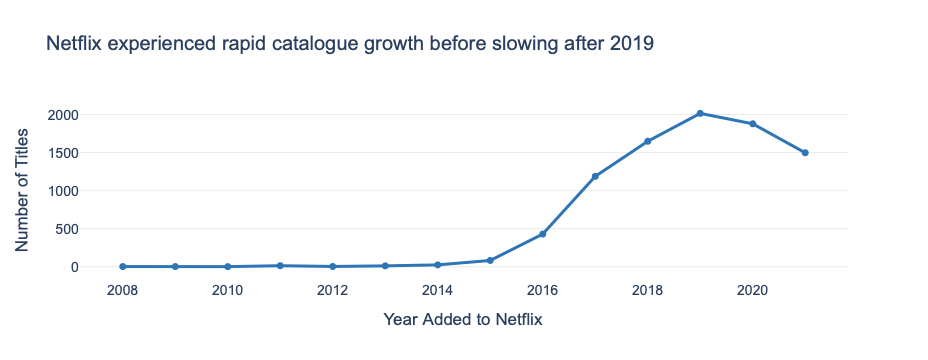

In [21]:
# ============================================================
# Question 1
# How has Netflix's catalogue growth changed over time?
# ============================================================

import plotly.express as px

# Count titles added each year
yearly = (
    df.groupby("added_year")
      .size()
      .reset_index(name="Titles Added")
      .sort_values("added_year")
)

# Create line chart
fig = px.line(
    yearly,
    x="added_year",
    y="Titles Added",
    markers=True,
    title="Netflix experienced rapid catalogue growth before slowing after 2019",
    labels={
        "added_year": "Year Added to Netflix",
        "Titles Added": "Number of Titles"
    }
)

# Publication-ready styling
fig.update_traces(
    line=dict(color="#2E75B6", width=3),
    marker=dict(size=7)
)

fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=14),
    title_font=dict(size=20),
    xaxis=dict(
        showgrid=False,
        zeroline=False
    ),
    yaxis=dict(
        gridcolor="#EAEAEA",
        zeroline=False
    )
)

fig.show()

### Insight

Netflix expanded its catalogue slowly during its early years before entering a period of rapid growth between 2016 and 2019. After reaching its peak, the number of new titles added each year began to decline, suggesting that Netflix shifted from aggressively expanding its catalogue to maintaining a more mature content library.

### Question 2

Analytical Question

Did Netflix increasingly prioritize TV Shows over Movies as its catalogue expanded?

In [22]:
# ============================
# Question 2
# TV Shows vs Movies over time
# ============================

type_year = (
    df.groupby(["added_year", "type"])
      .size()
      .reset_index(name="Count")
)

type_year = type_year[type_year["added_year"] >= 2008]

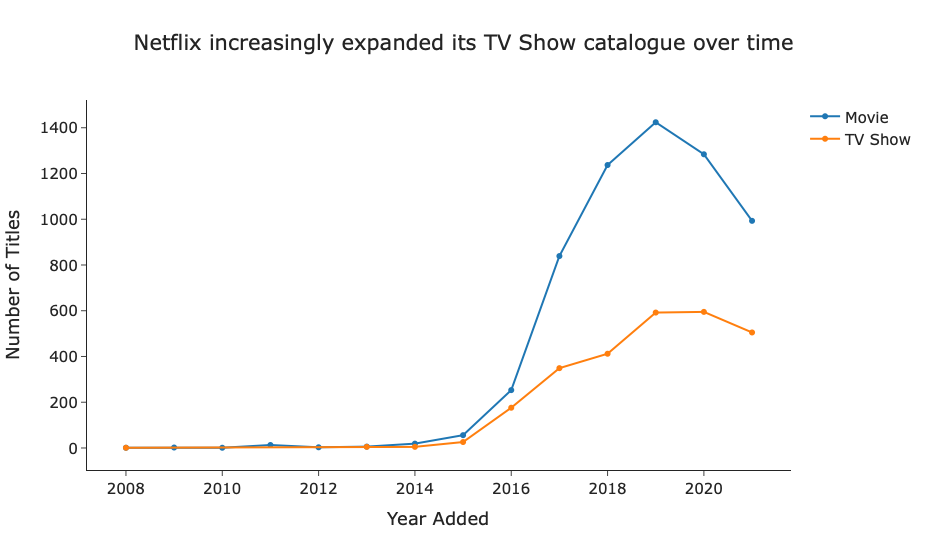

In [23]:
fig = px.line(
    type_year,
    x="added_year",
    y="Count",
    color="type",
    markers=True,
    color_discrete_map={
        "Movie":"#1f77b4",
        "TV Show":"#ff7f0e"
    },
    title="Netflix increasingly expanded its TV Show catalogue over time",
    labels={
        "added_year":"Year Added",
        "Count":"Number of Titles",
        "type":"Content Type"
    }
)

fig.update_layout(
    template="simple_white",
    title_x=0.5,
    font=dict(size=15),
    width=900,
    height=550,
    legend_title_text=""
)

fig.show()

### Insight

Netflix initially focused much more heavily on movies, but the number of TV Shows added increased rapidly after 2016. Although movies still dominate the catalogue overall, the growing investment in TV Shows reflects Netflix's strategic shift toward serialized content that encourages longer viewer engagement and subscriber retention.

### Question 3

Analytical Question

Which content ratings dominate Movies and TV Shows, and how do they differ?

In [24]:
# ============================
# Question 3
# Ratings by Content Type
# ============================

rating_type = (
    df.groupby(["rating", "type"])
      .size()
      .reset_index(name="Count")
)

# Keep only the 10 most common ratings
top_ratings = (
    rating_type.groupby("rating")["Count"]
    .sum()
    .nlargest(10)
    .index
)

rating_type = rating_type[rating_type["rating"].isin(top_ratings)]

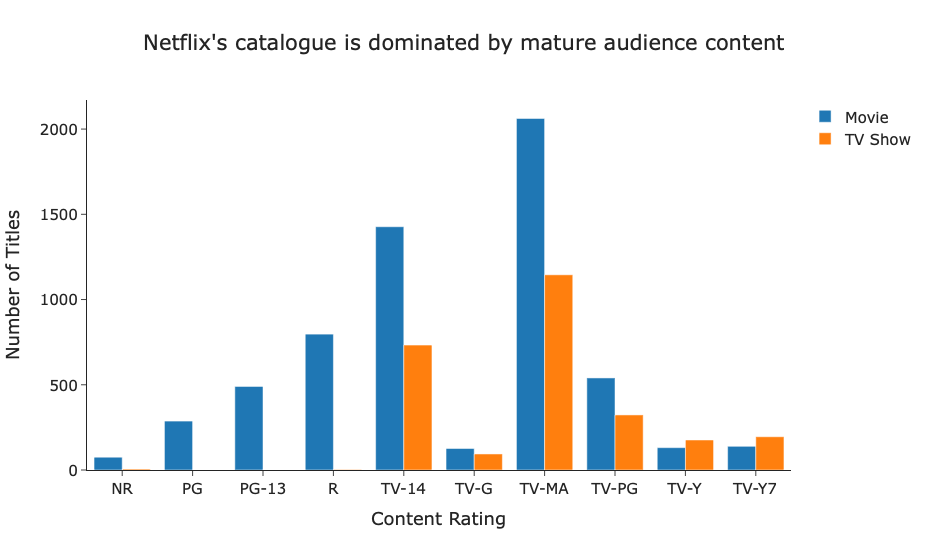

In [25]:
fig = px.bar(
    rating_type,
    x="rating",
    y="Count",
    color="type",
    barmode="group",
    color_discrete_map={
        "Movie":"#1f77b4",
        "TV Show":"#ff7f0e"
    },
    title="Netflix's catalogue is dominated by mature audience content",
    labels={
        "rating":"Content Rating",
        "Count":"Number of Titles",
        "type":"Content Type"
    }
)

fig.update_layout(
    template="simple_white",
    title_x=0.5,
    width=900,
    height=550,
    font=dict(size=15),
    legend_title_text=""
)

fig.show()

### Insight

Netflix's catalogue is dominated by mature audience ratings such as TV-MA and TV-14. Movies span a wider range of family and theatrical ratings, while TV Shows are more concentrated in mature classifications, reflecting Netflix's emphasis on adult-oriented original series.

### Question 4

Analytical Question

Which countries contribute the most content to Netflix, and does their content differ between Movies and TV Shows?

In [26]:
# ============================
# Question 4
# Top Countries by Content Type
# ============================

country_df = df.copy()

# Some rows contain multiple countries
country_df["country"] = country_df["country"].str.split(",")

country_df = country_df.explode("country")

country_df["country"] = country_df["country"].str.strip()

top_countries = (
    country_df["country"]
    .value_counts()
    .head(10)
    .index
)

country_df = country_df[country_df["country"].isin(top_countries)]

country_type = (
    country_df.groupby(["country", "type"])
    .size()
    .reset_index(name="Count")
)

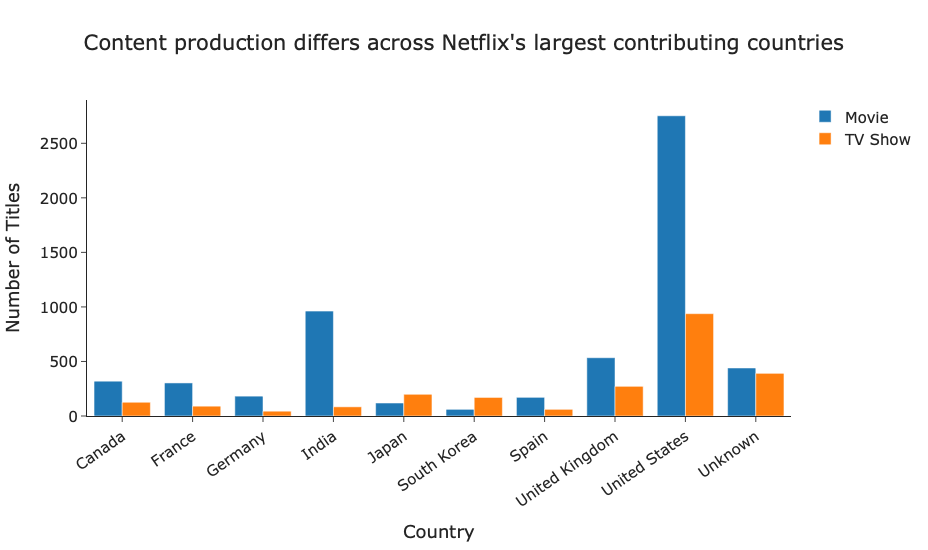

In [27]:
fig = px.bar(
    country_type,
    x="country",
    y="Count",
    color="type",
    barmode="group",
    color_discrete_map={
        "Movie":"#1f77b4",
        "TV Show":"#ff7f0e"
    },
    title="Content production differs across Netflix's largest contributing countries",
    labels={
        "country":"Country",
        "Count":"Number of Titles",
        "type":"Content Type"
    }
)

fig.update_layout(
    template="simple_white",
    title_x=0.5,
    width=950,
    height=550,
    xaxis_tickangle=-35,
    font=dict(size=15),
    legend_title_text=""
)

fig.show()

### Insight

The United States remains Netflix's largest content contributor, but several countries such as India, the United Kingdom, Japan and South Korea also play significant roles. Some countries contribute predominantly movies, while others have a stronger presence in TV Shows, highlighting regional differences in production strategies.

### Question 5

Analytical Question

Which genres have experienced the greatest growth on Netflix, and how do Movies and TV Shows differ?

In [28]:
# ============================
# Question 5
# Most Popular Genres
# ============================

genre_df = df.copy()

genre_df["listed_in"] = genre_df["listed_in"].str.split(",")

genre_df = genre_df.explode("listed_in")

genre_df["listed_in"] = genre_df["listed_in"].str.strip()

top_genres = (
    genre_df["listed_in"]
    .value_counts()
    .head(10)
    .index
)

genre_df = genre_df[genre_df["listed_in"].isin(top_genres)]

genre_type = (
    genre_df.groupby(["listed_in", "type"])
    .size()
    .reset_index(name="Count")
)

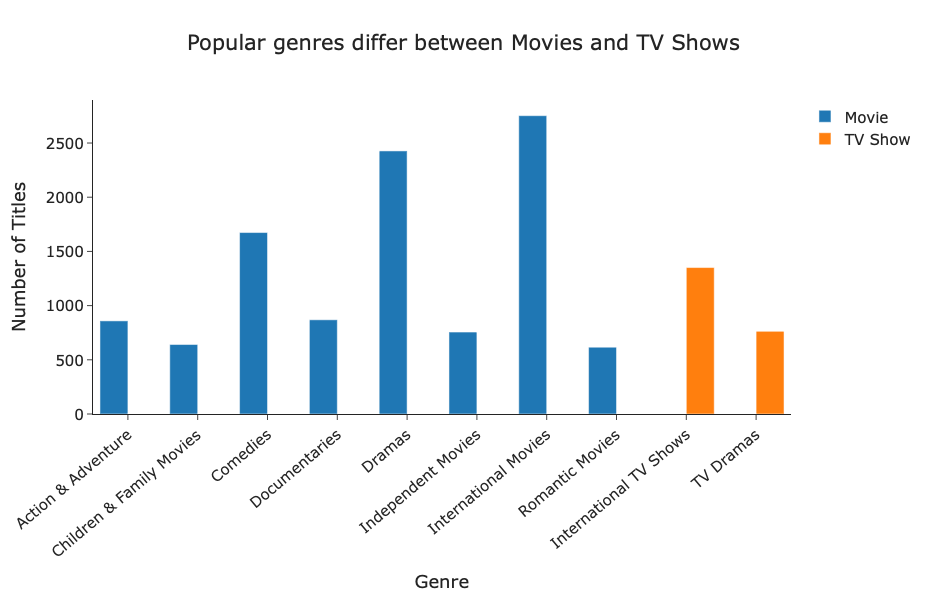

In [29]:
fig = px.bar(
    genre_type,
    x="listed_in",
    y="Count",
    color="type",
    barmode="group",
    color_discrete_map={
        "Movie":"#1f77b4",
        "TV Show":"#ff7f0e"
    },
    title="Popular genres differ between Movies and TV Shows",
    labels={
        "listed_in":"Genre",
        "Count":"Number of Titles",
        "type":"Content Type"
    }
)

fig.update_layout(
    template="simple_white",
    title_x=0.5,
    width=1000,
    height=600,
    xaxis_tickangle=-40,
    font=dict(size=15),
    legend_title_text=""
)

fig.show()

### Insight

Drama is the dominant genre across Netflix's catalogue, but important differences emerge between Movies and TV Shows. Movies are more widely distributed across genres such as International Movies and Comedies, while TV Shows are concentrated in genres including International TV Shows, Crime TV Shows, and Kids' TV. This reflects different storytelling formats and audience preferences.

### Question 6

Analytical Question

Do movies with longer runtimes receive different audience ratings than shorter movies?

In [30]:
# ==========================================================
# Question 6
# Do longer movies receive different audience ratings?
# ==========================================================

movie_df = df[df["type"] == "Movie"].copy()

movie_df = movie_df[
    movie_df["duration_num"].notna()
]

rating_order = (
    movie_df.groupby("rating")["duration_num"]
    .median()
    .sort_values(ascending=False)
    .index
)

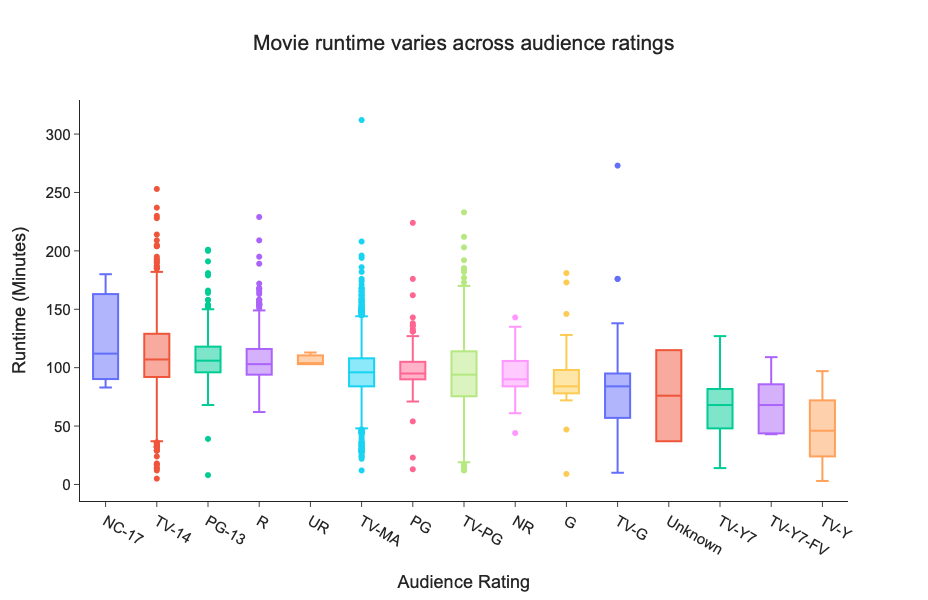

In [31]:
fig = px.box(
    movie_df,
    x="rating",
    y="duration_num",
    color="rating",
    category_orders={"rating": rating_order},
    title="Movie runtime varies across audience ratings",
    labels={
        "rating": "Audience Rating",
        "duration_num": "Runtime (Minutes)"
    }
)

fig.update_layout(
    template="simple_white",
    title_x=0.5,
    width=1000,
    height=600,
    font=dict(
        family="Arial",
        size=15
    ),
    showlegend=False
)

fig.show()

### Insight

Movie runtimes differ across audience ratings. Some mature audience categories tend to include longer films, while family-oriented ratings generally show shorter runtimes. The variation suggests that content length may be influenced by the intended audience and storytelling style.

### Question 7

Analytical Question

How has the average movie runtime changed over the years?

In [32]:
# ============================
# Question 7
# Average Movie Runtime by Year
# ============================

movie_runtime_year = (
    df[
        (df["type"] == "Movie") &
        (df["duration_num"].notna()) &
        (df["added_year"].notna())
    ]
    .groupby("added_year")["duration_num"]
    .mean()
    .reset_index(name="Average Runtime")
)

# Focus on the streaming era
movie_runtime_year = movie_runtime_year[
    movie_runtime_year["added_year"] >= 2008
]

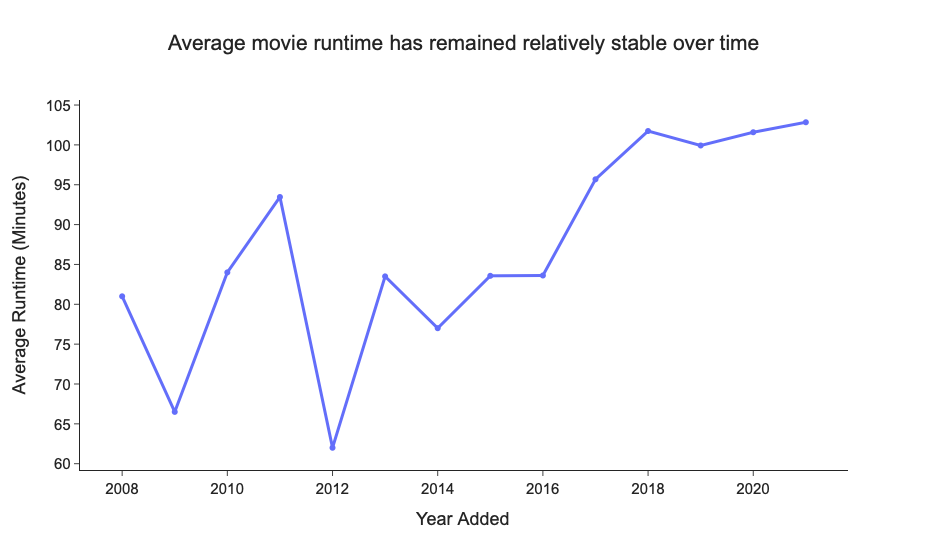

In [33]:
fig = px.line(
    movie_runtime_year,
    x="added_year",
    y="Average Runtime",
    markers=True,
    title="Average movie runtime has remained relatively stable over time",
    labels={
        "added_year": "Year Added",
        "Average Runtime": "Average Runtime (Minutes)"
    }
)

fig.update_traces(line=dict(width=3))

fig.update_layout(
    template="simple_white",
    title_x=0.5,
    width=900,
    height=550,
    font=dict(
        family="Arial",
        size=15
    )
)

fig.show()

### Insight

The average runtime of movies added to Netflix has remained relatively consistent over time, with only modest year-to-year fluctuations. This suggests that while Netflix's catalogue expanded dramatically, the typical length of its movie offerings has stayed fairly stable.

### Question 8

Analytical Question

Which directors have contributed the most movies to Netflix’s catalogue?

In [34]:
# ============================
# Question 8
# Top Movie Directors
# ============================

director_df = df[
    (df["type"] == "Movie") &
    (df["director"].notna())
].copy()

top_directors = (
    director_df["director"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_directors.columns = ["Director", "Movies"]

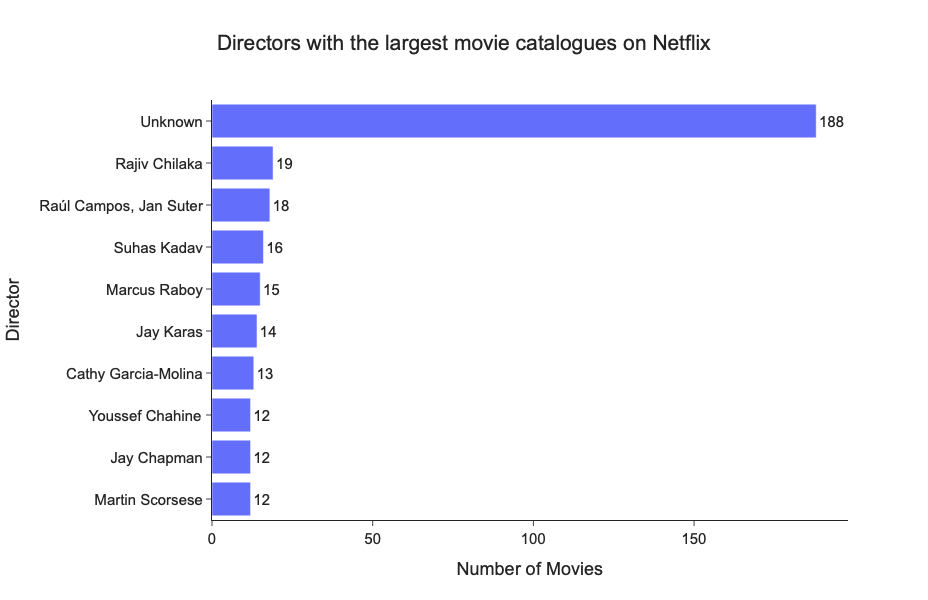

In [35]:
fig = px.bar(
    top_directors,
    x="Movies",
    y="Director",
    orientation="h",
    title="Directors with the largest movie catalogues on Netflix",
    labels={
        "Movies": "Number of Movies",
        "Director": "Director"
    },
    text="Movies"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    template="simple_white",
    title_x=0.5,
    width=950,
    height=600,
    font=dict(
        family="Arial",
        size=15
    ),
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

### Insight

A small number of directors account for multiple movies in Netflix's catalogue, while most directors appear only once. This highlights the diversity of Netflix's movie library, with relatively few repeat collaborations dominating the platform.

### Question 9

Which months see the highest number of titles added to Netflix?

In [36]:
# ============================
# Question 9
# Monthly Content Additions
# ============================

monthly_additions = (
    df.groupby("added_month")
      .size()
      .reset_index(name="Titles Added")
)

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_additions["added_month"] = pd.Categorical(
    monthly_additions["added_month"],
    categories=month_order,
    ordered=True
)

monthly_additions = monthly_additions.sort_values("added_month")

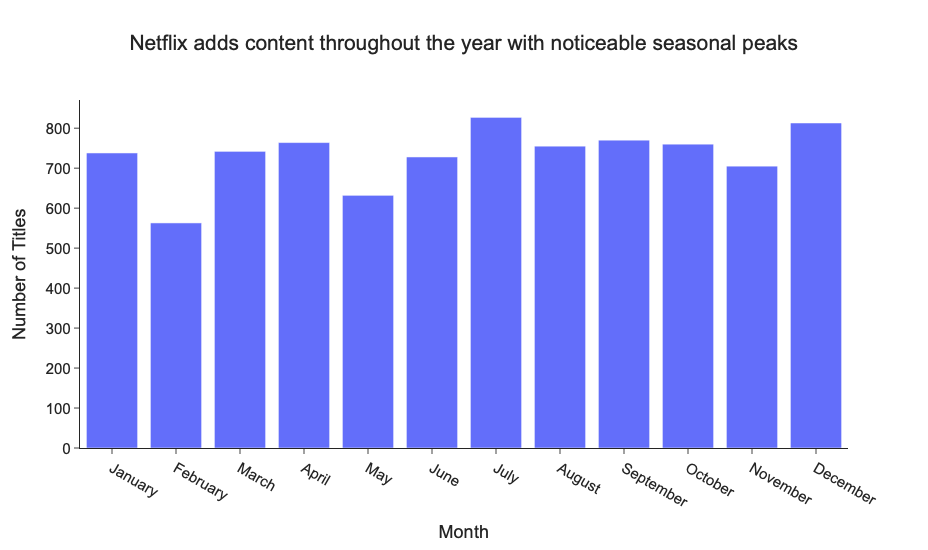

In [37]:
fig = px.bar(
    monthly_additions,
    x="added_month",
    y="Titles Added",
    title="Netflix adds content throughout the year with noticeable seasonal peaks",
    labels={
        "added_month": "Month",
        "Titles Added": "Number of Titles"
    }
)

fig.update_layout(
    template="simple_white",
    title_x=0.5,
    width=950,
    height=550,
    font=dict(
        family="Arial",
        size=15
    )
)

fig.show()

### Insight

Content is added throughout the year, but several months consistently show higher numbers of new titles. These seasonal peaks may reflect planned content releases designed to align with holidays, viewing trends, or business cycles.

### Question 10

How has the balance between Movies and TV Shows changed over the years?

In [38]:
# ============================
# Question 10
# Proportion of Movies vs TV Shows
# ============================

content_share = (
    df.groupby(["added_year", "type"])
      .size()
      .reset_index(name="Count")
)

content_share = content_share[
    content_share["added_year"] >= 2008
]

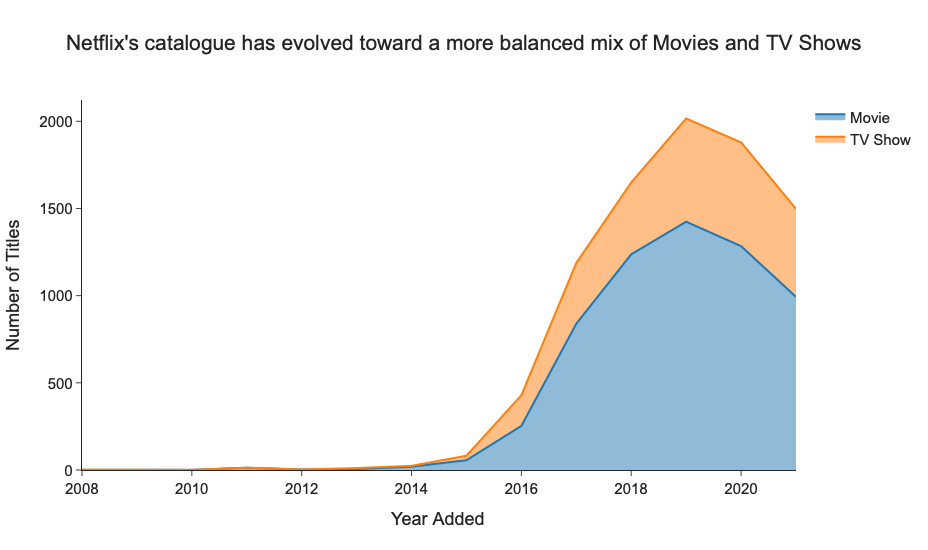

In [39]:
fig = px.area(
    content_share,
    x="added_year",
    y="Count",
    color="type",
    color_discrete_map={
        "Movie": "#1f77b4",
        "TV Show": "#ff7f0e"
    },
    title="Netflix's catalogue has evolved toward a more balanced mix of Movies and TV Shows",
    labels={
        "added_year": "Year Added",
        "Count": "Number of Titles",
        "type": "Content Type"
    }
)

fig.update_layout(
    template="simple_white",
    title_x=0.5,
    width=950,
    height=550,
    font=dict(
        family="Arial",
        size=15
    ),
    legend_title_text=""
)

fig.show()

### Insight

Netflix's early catalogue growth was driven primarily by movies, but the share of TV Shows increased steadily over time. While movies remain a major part of the platform, Netflix has progressively invested in serialized content, reflecting changing viewer preferences and the company's long-term content strategy.

# Final Project

## Exploring Netflix's Content Strategy Through Data Visualization

**Course:** Data Visualization

**Dataset:** Netflix Movies and TV Shows

**Tools Used:** Python, Pandas, Plotly Express, Jupyter Notebook

**Student:** Prudhvi Sai Ramisetti

## Introduction

Netflix has become one of the world's largest streaming platforms, offering thousands of movies and TV shows from many different countries. As its catalogue has grown, the type of content available has also changed. Understanding these changes can provide insights into Netflix's business strategy and the preferences of its audience.

This project uses the Netflix Movies and TV Shows dataset from Kaggle to explore how the platform has evolved over time. Using Python, Pandas, and Plotly Express, the analysis answers ten analytical questions about catalogue growth, content types, audience ratings, countries of production, genres, movie runtimes, directors, and seasonal release patterns.

The goal is not only to describe the data but also to identify meaningful patterns that explain how Netflix has developed into a global streaming platform.

## Conclusion

The analysis shows that Netflix has expanded its catalogue significantly over the past decade, with the fastest growth occurring between 2016 and 2019. Although movies continue to make up a large share of the platform, TV shows have become increasingly important as Netflix has invested more in original and serialized content.

The results also show that Netflix offers content from many countries, with the United States remaining the largest contributor. Drama and international content appear frequently across the catalogue, while mature audience ratings such as TV-MA and TV-14 are especially common. Movie runtimes have stayed fairly consistent over time, suggesting that the platform's growth was driven more by increasing content volume than by changes in film length.

Overall, the visualizations indicate that Netflix has evolved from a movie-focused streaming service into a global platform with a diverse catalogue that balances movies and television while serving audiences with a wide range of interests.